# Attention Notebook to Test If All the Models Focus on the Same Words

## Set Up from Previous

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy
import pandas as pd    # NEW – to store experiment results
import time             # NEW – to track runtime for each config

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [3]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [4]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


In [5]:
config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    # the rest of the keys aren't used in the attention notebook
}

model_param_path = os.path.join("..", "Model", "processed_full.w2v")

In [6]:
# Load Trained Models and Test Data

# Paths to the saved models (update if your filenames differ)
MODEL_PATHS = {
    "Centralized": "../History/models/central_best_attention.pt",
    "FedAvg":      "../History/models/fedavg_c2e3_best_attention.pt",
    "FedProx":     "../History/models/fedprox_c2e3_best_attention.pt",
    "SCAFFOLD":    "../History/models/scaffold_c2e3_best_attention.pt",
}

def load_model(path):
    model = GenerateModel(
        table_path=model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"],
    ).to(device)
    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

# Load all four models
models = {name: load_model(p) for name, p in MODEL_PATHS.items()}
print("Loaded models:", list(models.keys()))

# Load test set
X_test = torch.load(os.path.join("..", "Data", "X_test.pt"))
Y_test = torch.load(os.path.join("..", "Data", "Y_test.pt"))
test_dataset = TensorDataset(X_test, Y_test)
print("Test samples:", len(test_dataset))


Loaded models: ['Centralized', 'FedAvg', 'FedProx', 'SCAFFOLD']
Test samples: 1729


## Choose Labels and Gather Shared Positive Samples

In [7]:
def collect_positive_samples_for_labels(dataset, label_indices, n_per_label=5):
    label_indices = list(label_indices)
    idx_by_label = {lbl: [] for lbl in label_indices}

    for i, (_, y) in enumerate(dataset):
        y = y.long()
        for lbl in label_indices:
            if y[lbl] == 1 and len(idx_by_label[lbl]) < n_per_label:
                idx_by_label[lbl].append(i)
        if all(len(v) >= n_per_label for v in idx_by_label.values()):
            break

    return idx_by_label

def build_batch_from_indices(dataset, indices):
    X_list, Y_list = [], []
    for idx in indices:
        x, y = dataset[idx]
        X_list.append(x)
        Y_list.append(y)
    return torch.stack(X_list), torch.stack(Y_list)

# pick some label indices you care about
label_indices = [3, 7]   # example; change to interesting labels
sample_indices_by_label = collect_positive_samples_for_labels(
    test_dataset, label_indices, n_per_label=5
)
sample_indices_by_label


{3: [17, 29, 38, 55, 69], 7: [12, 16, 49, 76, 88]}

## Extract Attention for All Models and Labels

In [8]:
@torch.no_grad()
def get_attention_for_label(model, X_batch, label_idx):
    X_batch = X_batch.to(device)
    logits, alpha = model(X_batch)  # alpha: (B, label_space, seq_len)
    # attention for this label only
    alpha_label = alpha[:, label_idx, :].cpu()   # (B, seq_len)
    logits_label = logits[:, label_idx].cpu()
    return logits_label, alpha_label

attention_results = {}  # {model_name: {label_idx: {indices, logits, alpha}}}

for model_name, model in models.items():
    attention_results[model_name] = {}
    for lbl in label_indices:
        idxs = sample_indices_by_label[lbl]
        X_batch, Y_batch = build_batch_from_indices(test_dataset, idxs)
        logits_lbl, alpha_lbl = get_attention_for_label(model, X_batch, lbl)
        attention_results[model_name][lbl] = {
            "indices": idxs,
            "logits": logits_lbl,
            "alpha": alpha_lbl,   # shape (B, seq_len)
        }

# quick sanity check
for m in attention_results:
    for lbl in attention_results[m]:
        print(m, "label", lbl, "alpha shape:",
              attention_results[m][lbl]["alpha"].shape)


Centralized label 3 alpha shape: torch.Size([5, 2501])
Centralized label 7 alpha shape: torch.Size([5, 2501])
FedAvg label 3 alpha shape: torch.Size([5, 2501])
FedAvg label 7 alpha shape: torch.Size([5, 2501])
FedProx label 3 alpha shape: torch.Size([5, 2501])
FedProx label 7 alpha shape: torch.Size([5, 2501])
SCAFFOLD label 3 alpha shape: torch.Size([5, 2501])
SCAFFOLD label 7 alpha shape: torch.Size([5, 2501])


## Quantative

###  Simple attention visualization (position heatmaps)

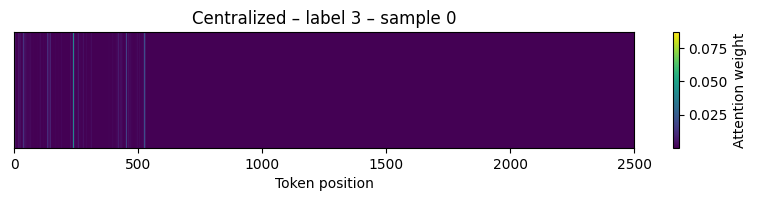

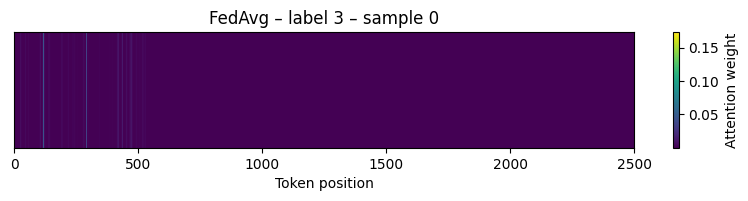

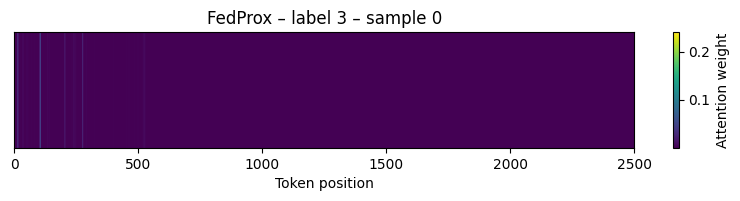

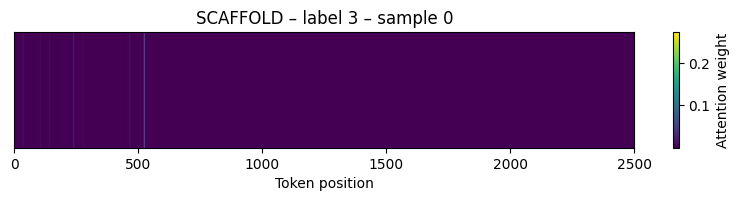

In [9]:
def plot_attention_heatmap(alpha_vec, title=""):
    plt.figure(figsize=(10, 1.5))
    plt.imshow(alpha_vec.unsqueeze(0).numpy(), aspect="auto")
    plt.colorbar(label="Attention weight")
    plt.yticks([])
    plt.xlabel("Token position")
    plt.title(title)
    plt.show()

# Example: first sample for first label, across all models
target_label = label_indices[0]
sample_in_batch = 0

for model_name in models.keys():
    alpha_batch = attention_results[model_name][target_label]["alpha"]
    alpha_vec = alpha_batch[sample_in_batch]  # (seq_len,)
    plot_attention_heatmap(
        alpha_vec,
        title=f"{model_name} – label {target_label} – sample {sample_in_batch}",
    )


### Similarity Metrics Between Models

In [10]:
import torch.nn.functional as F

def cosine_sim(a, b):
    # a, b: (seq_len,)
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

model_names = list(models.keys())

for lbl in label_indices:
    print(f"\n=== Label {lbl} ===")
    idx0 = sample_indices_by_label[lbl][0]
    X_batch, _ = build_batch_from_indices(test_dataset, [idx0])

    # collect one attention vector per model
    alpha_single = {}
    for name, model in models.items():
        _, alpha_lbl = get_attention_for_label(model, X_batch, lbl)
        alpha_single[name] = alpha_lbl[0]  # (seq_len,)

    # build similarity matrix
    sims = np.zeros((len(model_names), len(model_names)))
    for i, name_i in enumerate(model_names):
        for j, name_j in enumerate(model_names):
            sims[i, j] = cosine_sim(alpha_single[name_i], alpha_single[name_j])

    sim_df = pd.DataFrame(sims, index=model_names, columns=model_names)
    print(f"Cosine similarity of attention vectors for label {lbl}, sample idx {idx0}:")
    display(sim_df)



=== Label 3 ===
Cosine similarity of attention vectors for label 3, sample idx 17:


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000001,0.067476,0.106532,0.124547
FedAvg,0.067476,1.000000,0.090329,0.035203
FedProx,0.106532,0.090329,1.000000,0.084523
SCAFFOLD,0.124547,0.035203,0.084523,1.000007



=== Label 7 ===
Cosine similarity of attention vectors for label 7, sample idx 12:


,Centralized,FedAvg,FedProx,SCAFFOLD
Centralized,1.000005,0.889308,0.268025,0.496890
FedAvg,0.889308,1.000010,0.054852,0.119955
FedProx,0.268025,0.054852,1.000000,0.444769
SCAFFOLD,0.496890,0.119955,0.444769,1.000008


## Qualitative

### Recover Tokens from Input Sequences

In [11]:
from gensim.models import Word2Vec

# Load your W2V model to get the mapping index → token
w2v = Word2Vec.load(model_param_path)
idx_to_token = w2v.wv.index_to_key   # list where index maps to actual word

PAD_INDEX = len(idx_to_token)  # from ConvAttnPool padding_idx


### Decode a Sequence of Token IDs into Words

In [12]:
def decode_sequence(token_ids):
    tokens = []
    for idx in token_ids:
        idx = int(idx)
        if idx == PAD_INDEX:
            tokens.append("<PAD>")
        else:
            tokens.append(idx_to_token[idx])
    return tokens


### Visualize Attention By Token

In [13]:
def get_top_tokens(tokens, attention, k=15, skip_pad=True):
    """
    Return the top-k tokens by attention weight.
    tokens   : list[str]
    attention: 1D tensor of attention weights
    k        : how many tokens to return
    skip_pad : skip '<PAD>' tokens
    """
    att = attention.cpu().numpy()
    idxs = np.argsort(att)[::-1]  # highest first

    top = []
    for idx in idxs:
        tok = tokens[idx]
        if skip_pad and tok == "<PAD>":
            continue
        top.append((idx, tok, float(att[idx])))
        if len(top) >= k:
            break
    return top


In [14]:
from IPython.display import HTML

def attention_to_html(tokens, attention, max_color=240):
    att = attention / attention.max()
    html = ""
    for tok, w in zip(tokens, att):
        intensity = int(max_color * float(w))
        html += f"<span style='background-color: rgb(255,255,{255-intensity}); padding:2px; margin:1px;'>{tok}</span>"
    return HTML(html)

def show_attention(model_name, label_idx, sample_dataset_idx=0, top_k=15):
    # get the sample
    x, y = test_dataset[sample_dataset_idx]
    tokens = decode_sequence(x)

    # get attention weights for this model + label
    logits, alpha = get_attention_for_label(models[model_name], x.unsqueeze(0), label_idx)
    attention_vec = alpha[0]  # shape (seq_len,)

    print(f"\nModel: {model_name} | Label: {label_idx} | Sample index: {sample_dataset_idx}")
    display(attention_to_html(tokens, attention_vec))

    # print top-k tokens by attention
    top = get_top_tokens(tokens, attention_vec, k=top_k)
    print(f"Top {top_k} tokens by attention:")
    for pos, tok, w in top:
        print(f"  pos={pos:4d}  att={w:.4f}  token='{tok}'")


### Compare Qualitative Attention Across Models

In [15]:
target_label = 7          # ← change to any interesting label
sample_idx    = 123       # ← a test sample index

for model_name in models.keys():
    show_attention(model_name, target_label, sample_idx)



Model: Centralized | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 310  att=0.0307  token='mg'
  pos=  20  att=0.0224  token='pain'
  pos= 561  att=0.0160  token='needed'
  pos= 350  att=0.0154  token='and'
  pos=  90  att=0.0141  token='pain'
  pos= 425  att=0.0135  token='admission'
  pos= 174  att=0.0133  token='dry'
  pos= 681  att=0.0131  token='cecal'
  pos= 123  att=0.0131  token='cecal'
  pos= 119  att=0.0129  token='ulcer'
  pos= 677  att=0.0129  token='ulcer'
  pos= 157  att=0.0116  token='b'
  pos= 339  att=0.0108  token='propofol'
  pos= 162  att=0.0106  token='weight'
  pos= 806  att=0.0100  token='down'

Model: FedAvg | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 329  att=0.0465  token='note'
  pos= 173  att=0.0414  token='skin'
  pos= 358  att=0.0358  token='as'
  pos= 322  att=0.0357  token='room'
  pos= 398  att=0.0273  token='he'
  pos= 271  att=0.0238  token='wbc'
  pos= 166  att=0.0205  token='obese'
  pos= 259  att=0.0179  token='wbc'
  pos= 247  att=0.0167  token='wbc'
  pos= 310  att=0.0161  token='mg'
  pos= 822  att=0.0132  token='lifting'
  pos= 363  att=0.0132  token='brief'
  pos= 379  att=0.0131  token='mobility'
  pos= 168  att=0.0122  token='male'
  pos= 212  att=0.0097  token='warm'

Model: FedProx | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 162  att=0.2666  token='weight'
  pos= 666  att=0.0709  token='discharge'
  pos= 325  att=0.0421  token='was'
  pos= 340  att=0.0177  token='he'
  pos= 329  att=0.0168  token='note'
  pos= 120  att=0.0154  token='h'
  pos= 678  att=0.0154  token='h'
  pos= 122  att=0.0115  token='bleeding'
  pos= 680  att=0.0115  token='bleeding'
  pos= 877  att=0.0104  token='with'
  pos= 657  att=0.0102  token='care'
  pos= 313  att=0.0095  token='course'
  pos= 175  att=0.0089  token='x'
  pos= 806  att=0.0085  token='down'
  pos= 337  att=0.0084  token='epinephrine'

Model: SCAFFOLD | Label: 7 | Sample index: 123


Top 15 tokens by attention:
  pos= 841  att=0.1060  token='office'
  pos= 902  att=0.1060  token='office'
  pos= 328  att=0.0283  token='operative'
  pos= 106  att=0.0243  token='this'
  pos= 107  att=0.0193  token='past'
  pos= 290  att=0.0164  token='creat'
  pos= 403  att=0.0147  token='rehab'
  pos= 811  att=0.0139  token='driving'
  pos= 807  att=0.0138  token='on'
  pos= 916  att=0.0120  token='person'
  pos= 855  att=0.0120  token='person'
  pos= 121  att=0.0119  token='o'
  pos= 679  att=0.0119  token='o'
  pos= 155  att=0.0117  token='o2'
  pos= 316  att=0.0110  token='he'
